In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mnassrib/jena-climate")

print("Path to dataset files:", path)

100%|██████████| 13.2M/13.2M [00:00<00:00, 69.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mnassrib/jena-climate/versions/1


In [ ]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("mnassrib/jena-climate")

print("Dataset Path:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'jena-climate' dataset.
Dataset Path: /kaggle/input/jena-climate
/kaggle/input/jena-climate/jena_climate_2009_2016.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Load dataset
df = pd.read_csv("/kaggle/input/jena-climate/jena_climate_2009_2016.csv")

df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
features = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']
data = df[features]

data = data.fillna(method='ffill')

/tmp/ipykernel_3057/3995244914.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, target_index=0, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_index])
    return np.array(X), np.array(y)

SEQ_LEN = 24
X, y = create_sequences(scaled_data, seq_length=SEQ_LEN)

print(X.shape, y.shape)

(420527, 24, 4) (420527,)


In [ ]:
train_size = int(0.7 * len(X))
val_size = int(0.2 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [ ]:
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)

    return rmse, mae, mse

In [ ]:
def build_rnn():
    model = models.Sequential([
        layers.SimpleRNN(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
        layers.SimpleRNN(32),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
def build_lstm():
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
        layers.LSTM(32),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
def build_gru():
    model = models.Sequential([
        layers.GRU(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
        layers.GRU(32),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
def build_bilstm():
    model = models.Sequential([
        layers.Bidirectional(layers.LSTM(64, return_sequences=True),
                             input_shape=(SEQ_LEN, len(features))),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(x.shape[-1])(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x


def build_transformer():
    inputs = layers.Input(shape=(SEQ_LEN, len(features)))

    x = transformer_block(inputs, 32, 2, 64)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
def train_model(model, name):
    print(f"\nTraining {name}...")

    early_stop = EarlyStopping(patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )

    return history

In [ ]:
%

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training RNN...
Epoch 1/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - loss: 9.6271e-04 - val_loss: 7.2438e-05
Epoch 2/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 7.6241e-05 - val_loss: 2.1702e-04
Epoch 3/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 6.4191e-05 - val_loss: 3.0700e-04
Epoch 4/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 6.0854e-05 - val_loss: 5.8772e-05
Epoch 5/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - loss: 5.1485e-05 - val_loss: 8.5742e-05
Epoch 6/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 4.2914e-05 - val_loss: 5.9063e-05
Epoch 7/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 3.8697e-05 - val_loss: 5.8689e-05
Epoch 8/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 3.2545e-05 - val_loss: 4.4028e-05
Epoch 9/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - loss: 2.7886e-05 - val_loss: 3.6305e-05
Epoch 10/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 2.6365e-05 - val_loss: 3.3514e-05
13

In [ ]:
results_df = pd.DataFrame(results, index=["RMSE", "MAE", "MSE"]).T
results_df

,RMSE,MAE,MSE
RNN,0.003676,0.002531,0.000014
LSTM,0.003885,0.002671,0.000015
GRU,0.003457,0.002260,0.000012
BiLSTM,0.003731,0.002509,0.000014
Transformer,0.026446,0.020713,0.000699


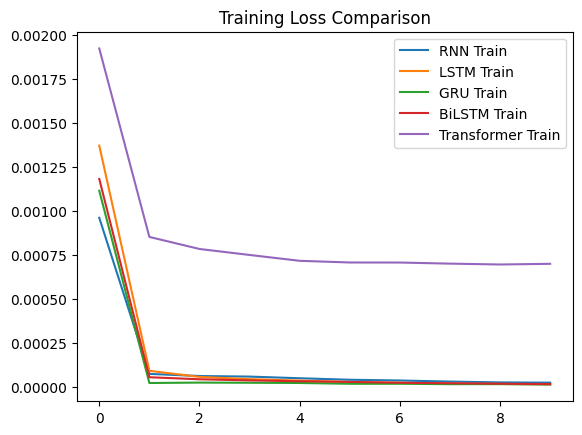

In [ ]:
for name, history in histories.items():
    plt.plot(history.history['loss'], label=f"{name} Train")

plt.title("Training Loss Comparison")
plt.legend()
plt.show()

1315/1315 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step


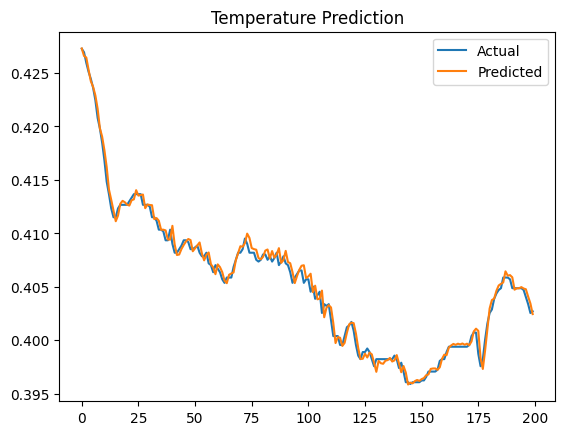

In [ ]:
best_model = models_dict["LSTM"]  # usually best for this dataset

pred = best_model.predict(X_test)

plt.plot(y_test[:200], label="Actual")
plt.plot(pred[:200], label="Predicted")
plt.legend()
plt.title("Temperature Prediction")
plt.show()

In [ ]:
optimizers = {
    "Adam": tf.keras.optimizers.Adam(),
    "SGD": tf.keras.optimizers.SGD(),
    "RMSprop": tf.keras.optimizers.RMSprop()
}

opt_results = {}

for name, opt in optimizers.items():
    model = build_lstm()
    model.compile(optimizer=opt, loss='mse')
    model.fit(X_train, y_train, epochs=5, batch_size=256, verbose=0)
    opt_results[name] = evaluate_model(model, X_test, y_test)

1315/1315 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1315/1315 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1315/1315 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step


In [ ]:
pd.DataFrame(opt_results, index=["RMSE", "MAE", "MSE"]).T

,RMSE,MAE,MSE
Adam,0.005093,0.003764,0.000026
SGD,0.021347,0.015913,0.000456
RMSprop,0.013937,0.012596,0.000194
